In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import string

import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from flonacomldft.utils.io_utils import (
    get_project_path
)

from flonacomldft.utils.plots import (
    load_ag6_image
)

In [3]:
np.random.seed(42)

In [4]:
methods = ['adaptive', 'mixture_model']

simulation_types = dict(zip( methods, [
                    ['ab-flowMC', 'ab-flowMC w.o. MLP'],
                    ['ab-flowMM', 'ab-flowMM w.o. MLP']
                ])
            )

# 1. Circular dichroism

In [5]:
path_opt_spc_dft = get_project_path() + '/8-optical-spectra'

## 1.a Free minima energy isomers 0K

In [6]:
data0K_is0 = np.loadtxt(path_opt_spc_dft +'/minima_is0/spectrum_with_05.50eV.dat', skiprows=1)
data0K_is1 = np.loadtxt(path_opt_spc_dft +'/minima_is1/spectrum_with_05.50eV.dat', skiprows=1)

## 1.b Molecular dynamics 350K

In [7]:
methods

['adaptive', 'mixture_model']

In [8]:
path_opt_spc_md = get_project_path() + '/8-optical-spectra/MD/'

data350K_is0_md = [np.loadtxt(path_opt_spc_md +'Ag6_1/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i),
                               skiprows=1) for i in range(50) if os.path.isfile(path_opt_spc_md +'Ag6_1/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i) ) ]
data350K_is1_md = [np.loadtxt(path_opt_spc_md +'Ag6_2/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i),
                                 skiprows=1) for i in range(50) if os.path.isfile(path_opt_spc_md +'Ag6_2/index_{:d}/spectrum_with_05.50eV.dat'.format(
                                    i) ) ]

Ydata350K_is0_md = np.array([data350K_is0_md[i][:,2] for i in range(len(data350K_is0_md))])
Ydata350K_is1_md = np.array([data350K_is1_md[i][:,2] for i in range(len(data350K_is1_md))])

mean_is0_md = np.mean(Ydata350K_is0_md, axis=0)
std_is0_md = np.std(Ydata350K_is0_md, axis=0)/np.sqrt(Ydata350K_is0_md.shape[0])

mean_is1_md = np.mean(Ydata350K_is1_md, axis=0)
std_is1_md = np.std(Ydata350K_is1_md, axis=0)/np.sqrt(Ydata350K_is1_md.shape[0])

#len(data350K_is0_md), len(data350K_is1_md)

## 1.c AbflowMC 350K

In [9]:
simulation_idxs = { methods[0]: { simulation_types[methods[0]][0]: {
                        #0: 31959918,
                        #1: 319599111
                        #0: 31959917,
                        #1: 319599110,
                        #0: 31959916,
                        #1: 31959919,
                        #0: 32504326,
                        #1: 32510291,
                        0: 32606140,
                        1: 32606143
                    },

                    simulation_types[methods[0]][1]: {
                        0: 31961552,
                        1: 31961553
                    }
                },

                methods[1]: { 
                    simulation_types[methods[1]][0]:
                        33041081,
                        #32948391,
                        #32901861, paper 
                        #32760171, best 
                        #32094541,
                    simulation_types[methods[1]][1]:
                        32094594
                        
                }
            }

In [10]:
path_opt_spc_mlp = get_project_path() + '/9-optical-spectra-mlp'

data350K_is0_mlp = [np.loadtxt(path_opt_spc_mlp +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][0], i),
                               skiprows=1) for i in range(50) ]
data350K_is1_mlp = [np.loadtxt(path_opt_spc_mlp +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format(
                                    simulation_idxs[methods[0]]['ab-flowMC'][1], i),
                                 skiprows=1) for i in range(50) ]

Ydata350K_is0_mlp = np.array([data350K_is0_mlp[i][:,2] for i in range(len(data350K_is0_mlp))])
Ydata350K_is1_mlp = np.array([data350K_is1_mlp[i][:,2] for i in range(len(data350K_is1_mlp))])

mean_is0_mlp = np.mean(Ydata350K_is0_mlp, axis=0)
std_is0_mlp = np.std(Ydata350K_is0_mlp, axis=0)/np.sqrt(Ydata350K_is0_mlp.shape[0])

mean_is1_mlp = np.mean(Ydata350K_is1_mlp, axis=0)
std_is1_mlp = np.std(Ydata350K_is1_mlp, axis=0)/np.sqrt(Ydata350K_is1_mlp.shape[0])

## 1.d AbflowMC w.o. MLP 350K

In [11]:
n=50

data350K_is0_dft = [np.loadtxt(path_opt_spc_dft +'/is0_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][0], i), 
                           skiprows=1) for i in range(n)]

data350K_is1_dft = [np.loadtxt(path_opt_spc_dft +'/is1_{:d}/sample_{:d}/spectrum_with_05.50eV.dat'.format( 
                        simulation_idxs[methods[0]]['ab-flowMC w.o. MLP'][1], i),
                            skiprows=1) for i in range(n)]

Ydata350K_is0_dft = np.array([data350K_is0_dft[i][:,2] for i in range(n)])
Ydata350K_is1_dft = np.array([data350K_is1_dft[i][:,2] for i in range(n)])

mean_is0_dft = np.mean(Ydata350K_is0_dft, axis=0)
std_is0_dft = np.std(Ydata350K_is0_dft, axis=0)/np.sqrt(Ydata350K_is0_dft.shape[0])


mean_is1_dft = np.mean(Ydata350K_is1_dft, axis=0)
std_is1_dft = np.std(Ydata350K_is1_dft, axis=0)/np.sqrt(Ydata350K_is1_dft.shape[0])


# 2. Final data

In [12]:
data_circ_dichroism = { 'energy': data0K_is0[:,0],
                        'T0K_is0_dft': data0K_is0[:,2],
                        'T0K_is1_dft': data0K_is1[:,2],
                        'mean_350K_is0_mlp': mean_is0_mlp, 
                        'mean_350K_is1_mlp': mean_is1_mlp,
                        'std_350K_is0_mlp': std_is0_mlp,
                        'std_350K_is1_mlp': std_is1_mlp,
                        'mean_350K_is0_dft': mean_is0_dft, 
                        'mean_350K_is1_dft': mean_is1_dft,
                        'std_350K_is0_dft': std_is0_dft,
                        'std_350K_is1_dft': std_is1_dft,
                        'mean_350K_is0_md': mean_is0_md, 
                        'mean_350K_is1_md': mean_is1_md,
                        'std_350K_is0_md': std_is0_md,
                        'std_350K_is1_md': std_is1_md,
        }

In [13]:
opt_spc_colors = dict(zip(['T=OK', 'MD', 'ab-flowMC', 'ab-flowMC w.o. MLP'],
                        ['#808080', '#cdb332', '#CC3311', 
                        '#0077BB']))

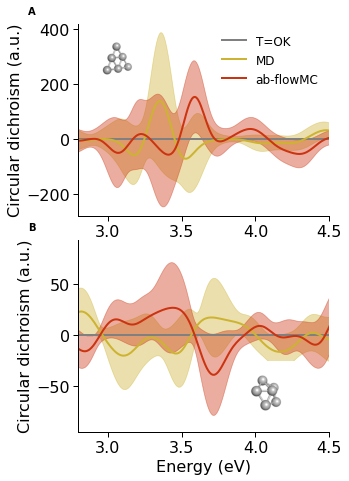

In [14]:
figsize=(4.5*1, 3.75*2)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.125
wspace=0.0

ncols = 1
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0]
ax2 = axs[1]

# -- item to subplot and delete top and right axis lines --

posx = -0.2
posy = 1.05

for n, ax in enumerate([ax1, ax2]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

n=50

from scipy.stats import t
t = t.ppf(1-0.05/2, n-1)

for i in range(2):
    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    axs[i].fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] - t*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] + t*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)

    #
    #sns.lineplot(x=data_circ_dichroism['energy'],
    #        y=data_circ_dichroism['mean_350K_is'+str(i)+'_dft'],
    #        linewidth=linewidth,
    #        ax=axs[i],
    #        color=opt_spc_colors['ab-flowMC w.o. MLP'],
    #        label='ab-flowMC \n w.o MLP'
    #        )
    #
    #axs[i].fill_between(
    #    data_circ_dichroism['energy'], 
    #    data_circ_dichroism['mean_350K_is'+str(i)+'_dft'] - t*data_circ_dichroism['std_350K_is'+str(i)+'_dft'], 
    #    data_circ_dichroism['mean_350K_is'+str(i)+'_dft'] + t*data_circ_dichroism['std_350K_is'+str(i)+'_dft'], 
    #    color=opt_spc_colors['ab-flowMC w.o. MLP'], alpha=0.2)

    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['ab-flowMC'],
            label='ab-flowMC'
            )
    
    axs[i].fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'] - t*data_circ_dichroism['std_350K_is'+str(i)+'_mlp'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'] + t*data_circ_dichroism['std_350K_is'+str(i)+'_mlp'], 
        color=opt_spc_colors['ab-flowMC'], alpha=0.4)
    

# -- set the limits of x and y axis --

ax1.set_ylabel('Circular dichroism (a.u.)')
ax2.set_ylabel('Circular dichroism (a.u.)')

for i in range(2):

    axs[i].set_xlabel('Energy (eV)')

    axs[i].set_xlim(2.8, 4.5)

ax1.legend(loc='best', frameon=False)
ax2.legend().remove()
ax1.set(xlabel=None)

# -- add image isomer --

l, b, h, w = ax1.get_position().get_points().flatten()
axsmall_1 = fig.add_axes([l*1.35, b*1.4, h*0.175, w*0.175])
axsmall_1.imshow(load_ag6_image(0))
axsmall_1.set_axis_off()

l, b, h, w = ax2.get_position().get_points().flatten()
axsmall_2 = fig.add_axes([l*4.8, b*1.1, h*0.245, w*0.245])
axsmall_2.imshow(load_ag6_image(1))
axsmall_2.set_axis_off()

#ax1.set_aspect('equal')
#ax2.set_aspect('equal')

# -- sharing axis subplots --

ax2.sharex(ax1)
#plt.setp(ax1.get_xticklabels(), visible=False)
#
#plt.savefig(path_save_figures+'/figure_3_optical.pdf',
#            dpi=300, 
#            facecolor='white',
#            transparent=False)

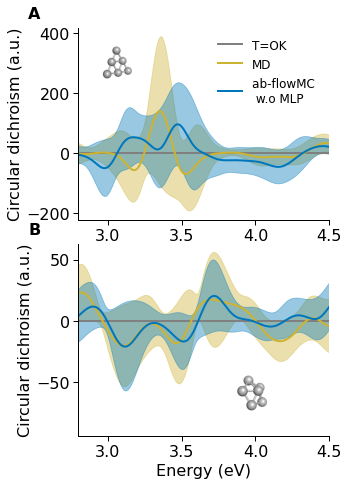

In [15]:
figsize=(4.5*1, 3.75*2)
fontsize=16
size_axes_label=16
size_tick_label=16
size_legend=12
linewidth=2
markersize=5
hspace=0.125
wspace=0.0

ncols = 1
nrows = 2

sns.set_context("paper", rc={"font.size":fontsize,
                    "axes.titlesize":fontsize,
                    "axes.labelsize":size_axes_label,
                    "xtick.labelsize":size_tick_label,
                    "ytick.labelsize":size_tick_label,
                    "legend.fontsize":size_legend,
                    })

# -- set figure --

fig, axs = plt.subplots(ncols=ncols,
                nrows=nrows,
                figsize=figsize,
                gridspec_kw={'wspace': wspace,
                            'hspace': hspace}
                            )

# -- set subplots --

ax1 = axs[0]
ax2 = axs[1]

# -- item to subplot and delete top and right axis lines --

posx = -0.2
posy = 1.05

for n, ax in enumerate([ax1, ax2]):
        
    ax.text(posx,
    posy,
    string.ascii_uppercase[n], 
    transform=ax.transAxes, 
    weight='bold')

    ax.spines[['right', 'top']].set_visible(False)

# -- plot opt spc --

n=50

from scipy.stats import t
t = t.ppf(1-0.05/2, n-1)

for i in range(2):
    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['T0K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['T=OK'],
            label='T=OK'
            )

    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_md'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['MD'],
            label='MD'
            )
    
    axs[i].fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] - t*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_md'] + t*data_circ_dichroism['std_350K_is'+str(i)+'_md'], 
        color=opt_spc_colors['MD'], alpha=0.4)

    
    sns.lineplot(x=data_circ_dichroism['energy'],
            y=data_circ_dichroism['mean_350K_is'+str(i)+'_dft'],
            linewidth=linewidth,
            ax=axs[i],
            color=opt_spc_colors['ab-flowMC w.o. MLP'],
            label='ab-flowMC \n w.o MLP'
            )
    
    axs[i].fill_between(
        data_circ_dichroism['energy'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_dft'] - t*data_circ_dichroism['std_350K_is'+str(i)+'_dft'], 
        data_circ_dichroism['mean_350K_is'+str(i)+'_dft'] + t*data_circ_dichroism['std_350K_is'+str(i)+'_dft'], 
        color=opt_spc_colors['ab-flowMC w.o. MLP'], alpha=0.4)

    
    #sns.lineplot(x=data_circ_dichroism['energy'],
    #        y=data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'],
    #        linewidth=linewidth,
    #        ax=axs[i],
    #        color=opt_spc_colors['ab-flowMC'],
    #        label='ab-flowMC'
    #        )
    #
    #axs[i].fill_between(
    #    data_circ_dichroism['energy'], 
    #    data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'] - t*data_circ_dichroism['std_350K_is'+str(i)+'_mlp'], 
    #    data_circ_dichroism['mean_350K_is'+str(i)+'_mlp'] + t*data_circ_dichroism['std_350K_is'+str(i)+'_mlp'], 
    #    color=opt_spc_colors['ab-flowMC'], alpha=0.2)
    

# -- set the limits of x and y axis --

ax1.set_ylabel('Circular dichroism (a.u.)')
ax2.set_ylabel('Circular dichroism (a.u.)')

for i in range(2):

    axs[i].set_xlabel('Energy (eV)')

    axs[i].set_xlim(2.8, 4.5)

ax1.legend(loc='best', frameon=False)
ax2.legend().remove()
ax1.set(xlabel=None)

# -- add image isomer --

l, b, h, w = ax1.get_position().get_points().flatten()
axsmall_1 = fig.add_axes([l*1.35, b*1.4, h*0.175, w*0.175])
axsmall_1.imshow(load_ag6_image(0))
axsmall_1.set_axis_off()

l, b, h, w = ax2.get_position().get_points().flatten()
axsmall_2 = fig.add_axes([l*4.45, b*1.15, h*0.245, w*0.245])
axsmall_2.imshow(load_ag6_image(1))
axsmall_2.set_axis_off()

#ax1.set_aspect('equal')
#ax2.set_aspect('equal')

# -- sharing axis subplots --

ax2.sharex(ax1)
#plt.setp(ax1.get_xticklabels(), visible=False)
#
#plt.savefig(path_save_figures+'/figure_3_optical.pdf',
#            dpi=300, 
#            facecolor='white',
#            transparent=False)